In [1]:
%pip install pygad


   -------------------- ------------------- 1/2 [pygad]
   -------------------- ------------------- 1/2 [pygad]
   ---------------------------------------- 2/2 [pygad]

Note: you may need to restart the kernel to use updated packages.


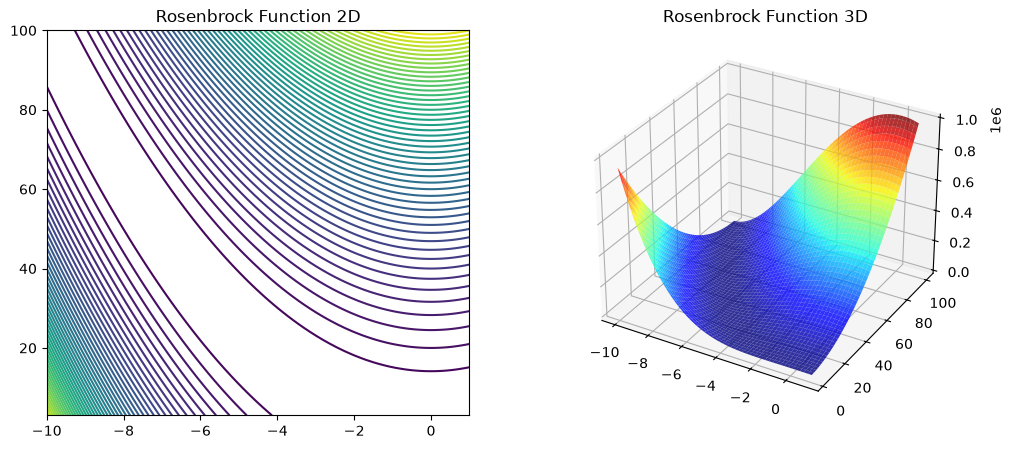

Initial guess [-1, 2], Result: [0.99999525 0.99999047], Value: 2.2680891685952225e-11, Success: True, Iterations: 35, Time: 0.0149 sec
Initial guess [-1.6, 2], Result: [0.99999552 0.99999104], Value: 2.0056460117423114e-11, Success: True, Iterations: 38, Time: 0.0668 sec
Initial guess [4.34, -1.5], Result: [0.99999552 0.99999104], Value: 2.00557414220439e-11, Success: True, Iterations: 68, Time: 0.0338 sec
PyGAD initial guess [-1, 2], Solution: [1.01595528 1.03597289], Value: 0.0017044674450940695, iterations: 100, Time: 0.0530 sec
PyGAD initial guess [-1.6, 2], Solution: [0.93738474 0.86503092], Value: 0.02257811044013379, iterations: 100, Time: 0.0449 sec
PyGAD initial guess [4.34, -1.5], Solution: [1.26393565 1.60008344], Value: 0.07031233272213246, iterations: 100, Time: 0.0628 sec


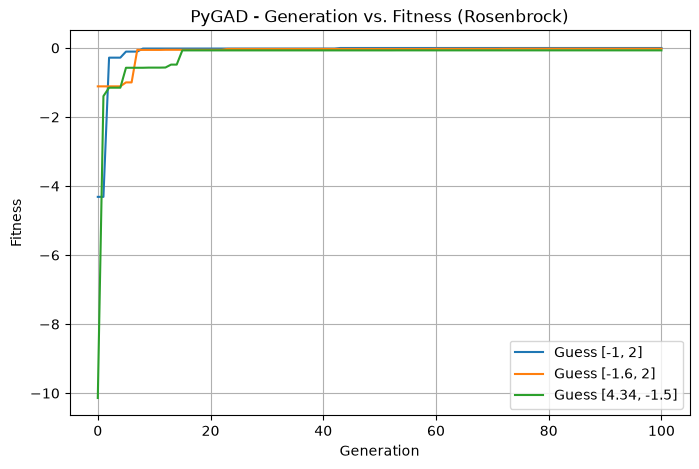

In [24]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    def rosenbrock(x):
        x = np.asarray(x)
        return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(1, -10, 17650)
y_range = np.linspace(3, 100, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
# Fix the Rosenbrock definition so it returns a 2D array for the meshgrid
def rosenbrock(x):
    x = np.asarray(x)
    return (1 - x[0]) ** 2 + 100 * (x[1] - x[0] ** 2) ** 2

Z = rosenbrock([X, Y])  # shape matches X and Y
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")
plt.show()

elapsed_time = []
# Scipy Optimization
init_guesses = [[-1, 2], [-1.6, 2], [4.34, -1.5]]
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")

# PyGAD Optimization
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution) # pygad maximizes, so negate


pygad_fitness_history = []

elapsed_time = []
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=100,
                           sol_per_pop=20,
                           num_genes=2,
                           num_parents_mating=8,
                           fitness_func=fitness_func,
                           init_range_low=-2,
                           init_range_high=2,
                           gene_space={'low':-2, 'high':2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    
  
    pygad_fitness_history.append((guess, ga_instance.best_solutions_fitness))
    
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {rosenbrock(solution)}, iterations: {iters}, Time: {elapsed_time:.4f} sec")
    # ga_instance.plot_fitness() 


plt.figure(figsize=(8, 5))
for guess, fitness in pygad_fitness_history:
    plt.plot(fitness, label=f"Guess {guess}")

plt.title("PyGAD - Generation vs. Fitness (Rosenbrock)")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)
plt.show()

The solution does not change with change in change in initial guess for gradient method. We find global minima
The gradient method computes the value in lesser time when compared to GA  
gradient method takes lesser iterations when compared to GA
gradient method provides more accurate results

BFGS,DFG


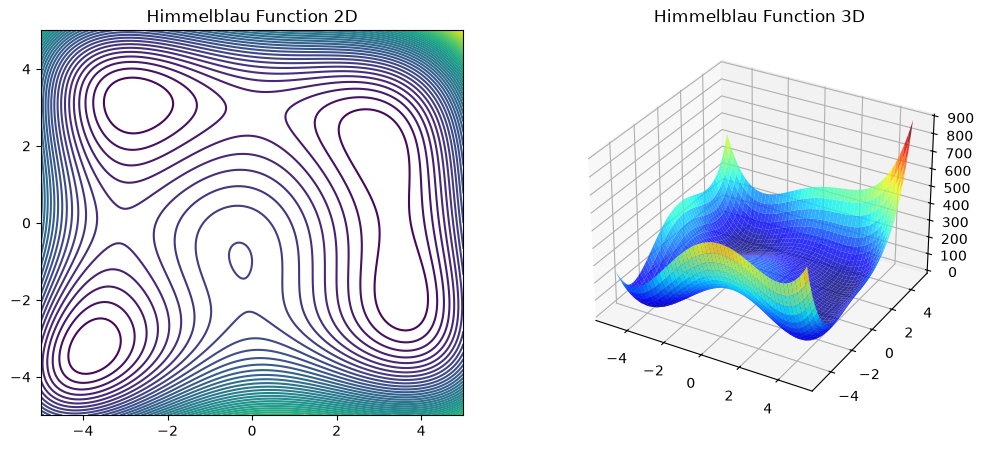

Initial guess [-1, 0], Result: [-2.80511809  3.13131251], Value: 5.557391261643948e-15, Success: True, Iterations: 10, Time: 0.0034 sec
Zmin: 0.0026386032654674846, Zmax: 890.0
Initial guess [-4, 4], Result: [-2.80511803  3.13131251], Value: 1.0206446176713682e-13, Success: True, Iterations: 10, Time: 0.0019 sec
Zmin: 0.0026386032654674846, Zmax: 890.0
Initial guess [4, 1], Result: [2.99999999 2.        ], Value: 7.219185663380434e-15, Success: True, Iterations: 9, Time: 0.0017 sec
Zmin: 0.0026386032654674846, Zmax: 890.0
PyGAD initial guess [-1, 0], Solution: [3.00777219 1.99561348], Value: 0.001885035994660705


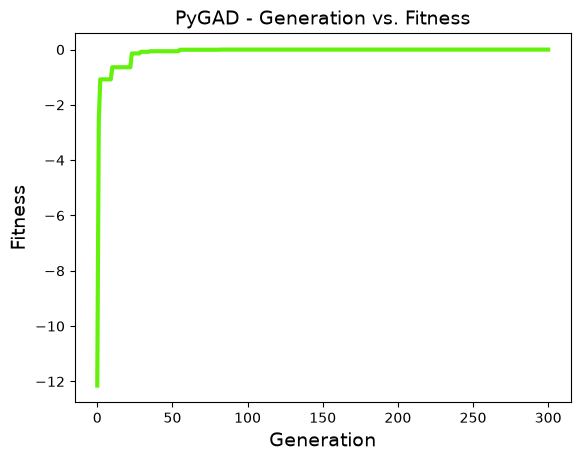

PyGAD initial guess [-4, 4], Solution: [ 3.60207992 -1.85241154], Value: 0.016145785717443996


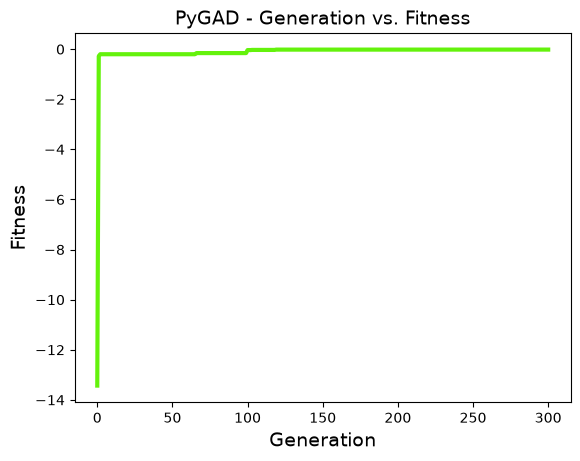

PyGAD initial guess [4, 1], Solution: [3.00646795 2.01194797], Value: 0.005540032164166906


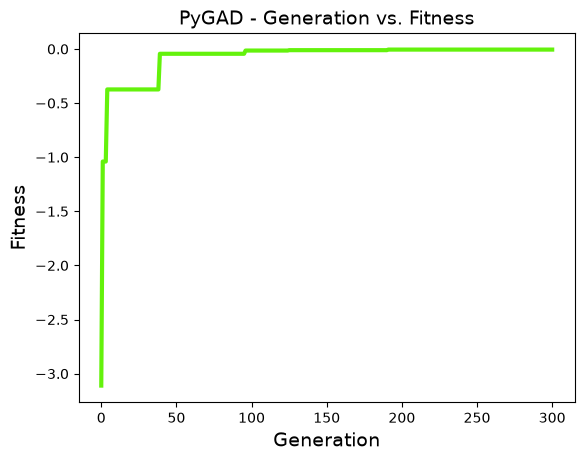

Time: 0.0017 sec, Iterations: 300


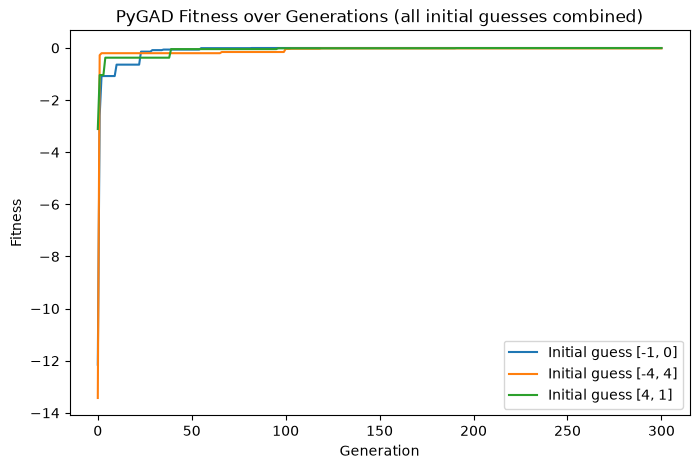

In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad
def himmelblau(x):
    x = np.asarray(x) # Convert to numpy array
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")
plt.savefig("himmelblau_2d3d.png")
plt.show()
# Scipy Optimization
init_guesses = [[-1, 0], [-4, 4], [4, 1]]
for guess in init_guesses:
    start_time = time.perf_counter()
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec") # TODO include time taken
    print(f"Zmin: {np.min(Z)}, Zmax: {np.max(Z)}")
# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)
all_fitness_histories = []  # added: collect each run's fitness history for the combined plot
for guess in init_guesses:
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}") # TODO include iterations and time taken
    ga_instance.plot_fitness()
    all_fitness_histories.append(ga_instance.best_solutions_fitness)  # added: store this run's history
print(f"Time: {elapsed_time:.4f} sec, Iterations: {ga_instance.generations_completed}")

# added: combine all PyGAD fitness curves onto a single graph using a for loop
plt.figure(figsize=(8, 5))
for i, history in enumerate(all_fitness_histories):
    plt.plot(history, label=f"Initial guess {init_guesses[i]}")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("PyGAD Fitness over Generations (all initial guesses combined)")
plt.legend()
plt.savefig("combined_fitness.png")
plt.show()



we find global minima in this case
The gradient method computes the value in lesser time when compared to GA  
gradient method takes lesser iterations when compared to GA
gradient method provides more accurate results


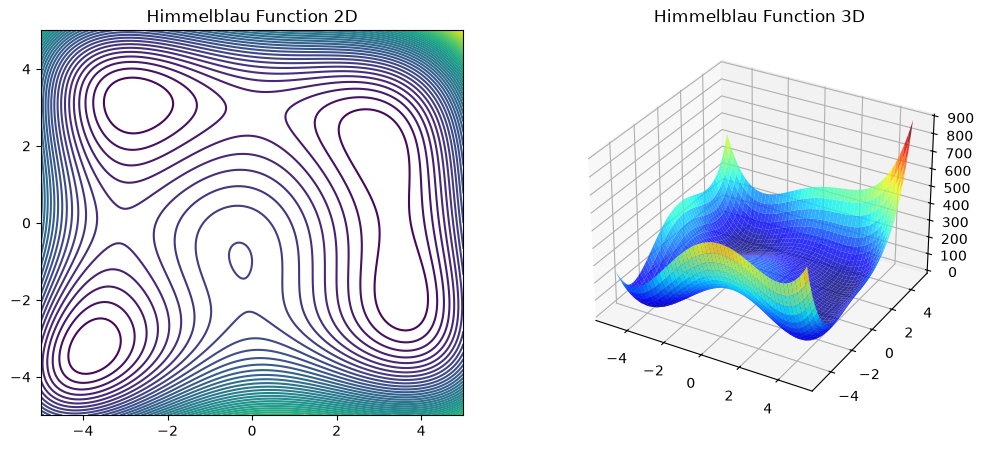

Initial guess [-1, 0], Result: [-2.80511809  3.13131251], Value: 5.557391261643948e-15, Success: True, Iterations: 10, Time: 0.0043 sec
Zmin: 0.0026386032654674846 Zmax: 890.0
None
Initial guess [-4, 1], Result: [-2.8051181  3.1313125], Value: 1.1816305601505916e-14, Success: True, Iterations: 7, Time: 0.0045 sec
Zmin: 0.0026386032654674846 Zmax: 890.0
None
Initial guess [4, 1.5], Result: [2.99999999 2.        ], Value: 1.2859968385052772e-15, Success: True, Iterations: 8, Time: 0.0024 sec
Zmin: 0.0026386032654674846 Zmax: 890.0
None
PyGAD initial guess [-1, 0], Solution: [-3.77686546 -3.28031159], Value: 0.0005129843659480709


c:\Users\Vaishnavi\miniconda3\envs\mude-base\Lib\site-packages\pygad\utils\validation.py:966: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


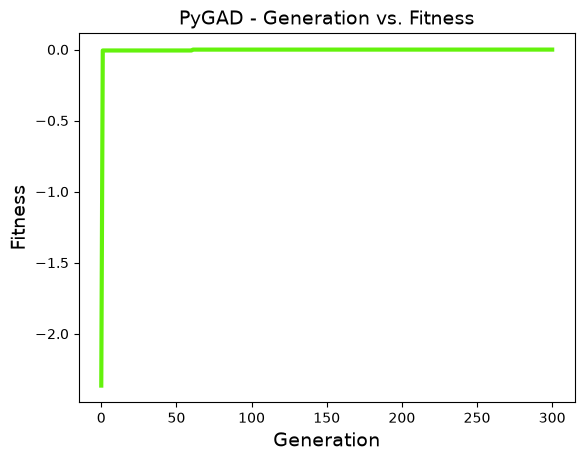

PyGAD initial guess [-4, 1], Solution: [ 3.57644975 -1.84039469], Value: 0.003772619018494918


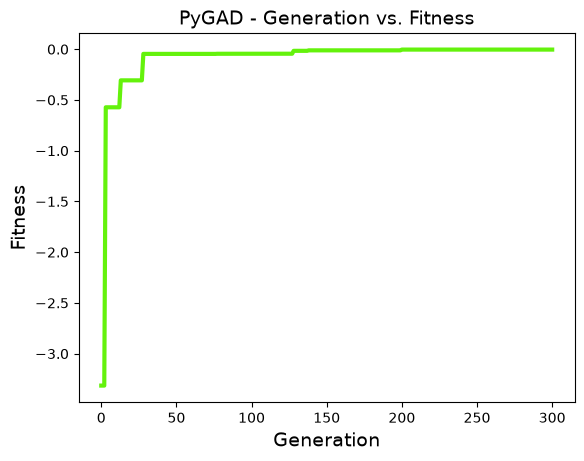

PyGAD initial guess [4, 1.5], Solution: [2.98351741 1.99797565], Value: 0.01073403504368844


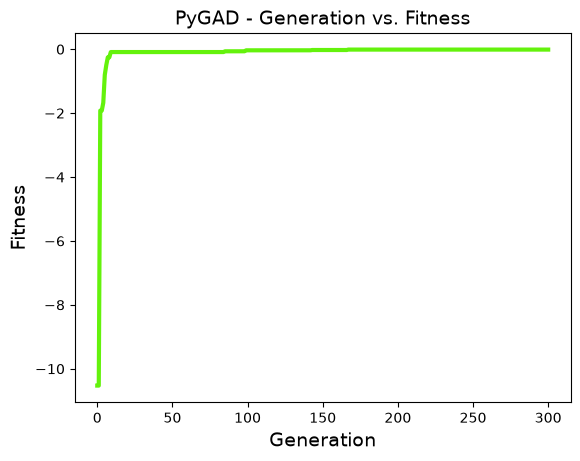

Time: 0.0024 sec, Iterations: 300


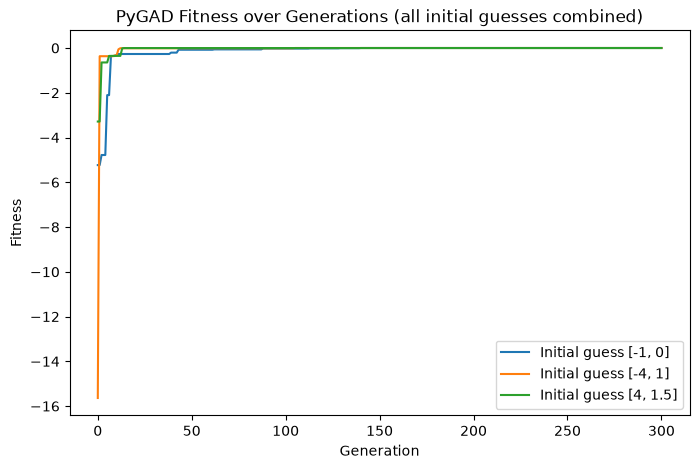

In [26]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad
def himmelblau(x):
    x = np.asarray(x) # Convert to numpy array
    y =np.asarray(y) # Convert to numpy array
    return (x**2 + y**2 - 1)**2 + (x -1)**2 +y**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
def himmelblau(x):
    x = np.asarray(x)
    return (x[0] ** 2 + x[1] - 11) ** 2 + (x[0] + x[1] ** 2 - 7) ** 2

Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")
plt.show()
# Scipy Optimization
init_guesses = [[-1, 0], [-4, 1], [4, 1.5]]
for guess in init_guesses:
    start_time = time.perf_counter()
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec") # TODO include time taken
    print(print("Zmin:", np.min(Z), "Zmax:", np.max(Z)))
# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)
for guess in init_guesses:
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}") # TODO include iterations and time taken
    ga_instance.plot_fitness()
print(f"Time: {elapsed_time:.4f} sec, Iterations: {ga_instance.generations_completed}")
plt.figure(figsize=(8, 5))
for i, history in enumerate(all_fitness_histories):
    plt.plot(history, label=f"Initial guess {init_guesses[i]}")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("PyGAD Fitness over Generations (all initial guesses combined)")
plt.legend()
plt.savefig("combined_fitness.png")
plt.show()


we find global minima in this case
The optimization function computes the value in lesser time when compared to GA  
optimization function takes lesser iterations when compared to GA
optimization function provides more accurate results